In [2]:
!pip install ultralytics -q

In [1]:
import torch
print(f"PyTorch: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")

PyTorch: 2.11.0+cu130
CUDA available: True
GPU: NVIDIA RTX 2000 Ada Generation


In [ ]:
import zipfile


zip_path = "/content/drive/MyDrive/irddt_dataset.zip"
extract_to = "/content/"

print(f"Extracting {zip_path}...")
with zipfile.ZipFile(zip_path, 'r') as z:
    z.extractall(extract_to)
print("Done!")

# Verify extraction
dataset_path = "/irddt_dataset"
for split in ["train", "val"]:
    imgs = len(os.listdir(os.path.join(dataset_path, "images", split)))
    lbls = len(os.listdir(os.path.join(dataset_path, "labels", split)))
    print(f"{split}: {imgs} images, {lbls} labels")

Extracting /content/drive/MyDrive/irddt_dataset.zip...
Done!
train: 42823 images, 42823 labels
val: 18949 images, 18949 labels


In [2]:
dataset_path = "/home/tarun/Desktop/V_Env/irddt_dataset"

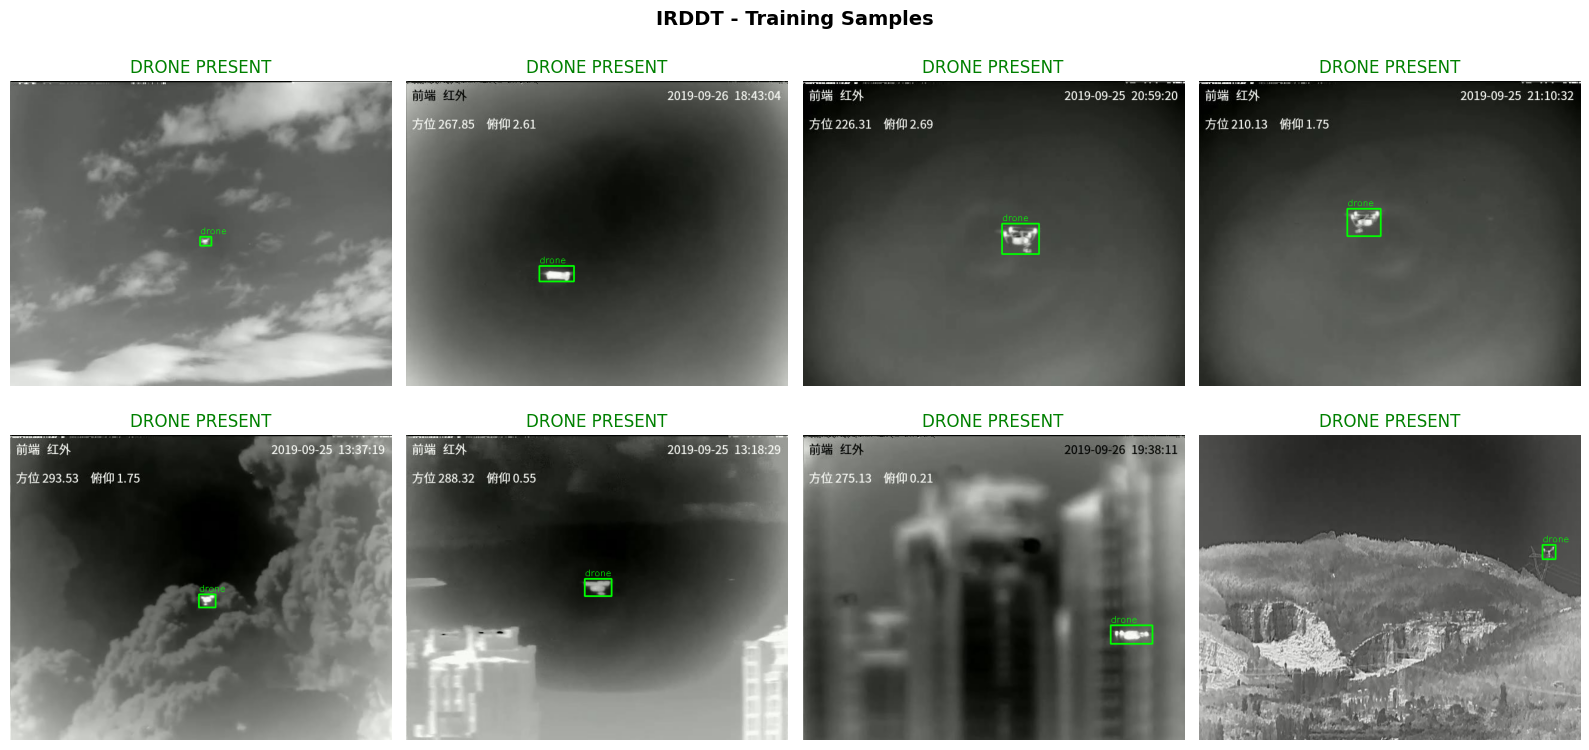

In [ ]:
import cv2
import os
import matplotlib.pyplot as plt
import numpy as np
import random

def show_sample(img_path, lbl_path, ax):
    """Drawing YOLO bbox on images."""
    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    h, w = img.shape[:2]

    with open(lbl_path) as f:
        content = f.read().strip()

    if content:
        parts = content.split()
        cx, cy, bw, bh = float(parts[1]), float(parts[2]), float(parts[3]), float(parts[4])
        # Convert back to pixel coords
        x1 = int((cx - bw/2) * w)
        y1 = int((cy - bh/2) * h)
        x2 = int((cx + bw/2) * w)
        y2 = int((cy + bh/2) * h)
        cv2.rectangle(img, (x1, y1), (x2, y2), (0, 255, 0), 2)
        cv2.putText(img, "drone", (x1, y1-5), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 255, 0), 1)
        ax.set_title("DRONE PRESENT", color='green')
    else:
        ax.set_title("NO DRONE", color='red')

    ax.imshow(img)
    ax.axis('off')

# Show 8 random samples
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
img_dir = os.path.join(dataset_path, "images", "train")
lbl_dir = os.path.join(dataset_path, "labels", "train")
samples = random.sample(os.listdir(img_dir), 8)

for ax, fname in zip(axes.flat, samples):
    img_path = os.path.join(img_dir, fname)
    lbl_path = os.path.join(lbl_dir, fname.replace('.jpg', '.txt'))
    show_sample(img_path, lbl_path, ax)

plt.suptitle("IRDDT - Training Samples", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [ ]:
from ultralytics import YOLO

# Loading pretrained YOLOv11 nano model
model = YOLO("yolo11n.pt")

# Training on our thermal drone dataset
results = model.train(
    data="/home/tarun/Desktop/V_Env/irddt_dataset/dataset.yaml",
    cache=True,
    epochs=50,
    imgsz=640,
    batch=64,
    patience=10,
    save=True,
    save_period=10,
    device=0,
    workers=24,
    # Augmentation tuned for thermal/IR images
    hsv_h=0.0,            # No hue shift for grayscale thermal images
    hsv_s=0.0,            # No saturation shift
    hsv_v=0.2,            # Slight brightness variation
    degrees=10,           # Small rotation
    translate=0.1,
    scale=0.3,            # Scale variation for drones at different distances
    fliplr=0.5,           # Horizontal flip
    flipud=0.0,           # No vertical flip
    mosaic=0.5,           # Mosaic augmentation
    mixup=0.1,            # Light mixup
)

print("\nTraining completed!")

In [ ]:
from ultralytics import YOLO

model = YOLO('/home/tarun/Desktop/V_Env/IRDDT/training/runs/detect/train/weights/last.pt')

# Resume training
model.train(resume=True)